В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням kNearestNeighboors, знайдемо оптимальні гіперпараметри для цього методу і зробимо базові ансамблі. Це дасть змогу порівняти перформанс моделі з попередніми вивченими методами.

0. Зчитайте дані `train.csv` та зробіть препроцесинг використовуючи написаний Вами скрипт `process_bank_churn.py` так, аби в результаті отримати дані в розбитті X_train, train_targets, X_val, val_targets для експериментів.

  Якщо Вам не вдалось реалізувати в завданні `2.3. Дерева прийняття рішень` скрипт `process_bank_churn.py` - можна скористатись готовим скриптом з запропонованого рішення того завдання.

In [1]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from process_bank_churn import preprocess_data, preprocess_new_data
from model_evaluation import evaluate_model, get_predictions

%load_ext autoreload
%autoreload 2

In [2]:
raw_df = pd.read_csv('train.csv')
data = preprocess_data(raw_df)

X_train = data['X_train']
train_targets = data['train_targets'].squeeze()
X_val = data['X_val']
val_targets = data['val_targets'].squeeze()
X_train

,Balance,HasCrCard,CustomerId,Tenure,CreditScore,Age,IsActiveMember,NumOfProducts,EstimatedSalary,GenderCode,Geography_France,Geography_Germany,Geography_Spain
8263,1.463179,0.512471,-0.077840,-0.008436,0.513193,-0.698563,1.017939,-1.109137,-0.683158,0,1.0,0.0,0.0
14199,1.282909,0.512471,0.755898,-0.367931,-0.374256,-0.698563,-0.982377,-1.109137,1.313519,1,0.0,1.0,0.0
1856,-0.716829,0.512471,-0.517135,-0.367931,0.277465,-1.926640,1.017939,0.771748,0.981199,1,1.0,0.0,0.0
3013,-0.716829,0.512471,-0.259404,-0.727425,0.637991,1.266360,-0.982377,0.771748,0.041916,0,1.0,0.0,0.0
8266,-0.716829,0.512471,0.514262,0.710553,0.513193,-0.330140,-0.982377,0.771748,-0.383769,1,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9493,-0.716829,-1.951331,0.134640,-0.367931,-0.360389,-0.575755,-0.982377,0.771748,0.123644,1,1.0,0.0,0.0
7687,0.744119,0.512471,-0.329416,-0.727425,-0.193993,-0.575755,-0.982377,-1.109137,0.376985,0,0.0,0.0,1.0
8143,-0.716829,0.512471,-0.702710,1.070048,-0.526786,-1.066986,1.017939,0.771748,0.343139,0,1.0,0.0,0.0
11512,-0.716829,-1.951331,0.022763,0.710553,-0.956644,0.529514,-0.982377,0.771748,-0.993634,0,0.0,0.0,1.0


1. Навчіть на цих даних класифікатор kNN з параметрами за замовченням і виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах. Зробіть заключення про отриману модель: вона хороша/погана, чи є high bias/high variance?

=== Train ===
AUROC:    0.9619
F1 Score: 0.7651


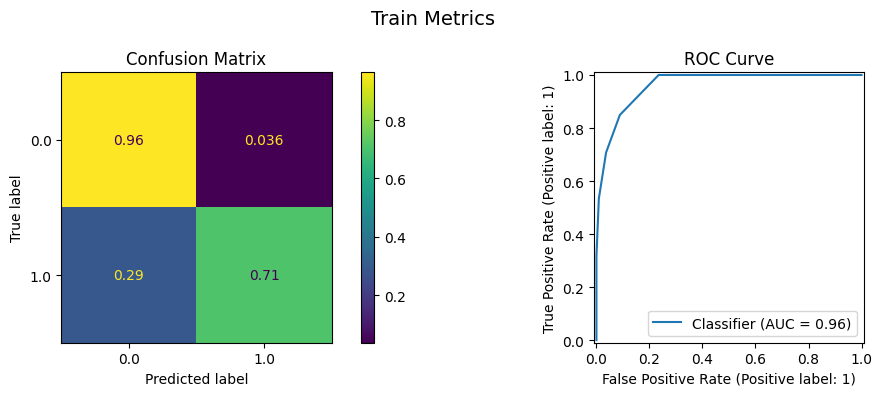

=== Validation ===
AUROC:    0.8703
F1 Score: 0.6720


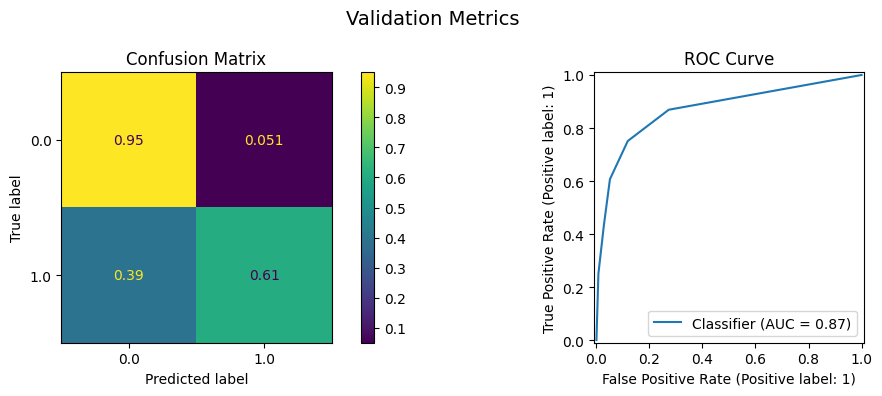

In [3]:
knn = KNeighborsClassifier()

knn.fit(X_train, train_targets)
knn.predict_proba(X_val)

evaluate_model(knn, X_train, train_targets, dataset_name='Train')
evaluate_model(knn, X_val, val_targets, dataset_name='Validation');

Модель не є хорошою  - AUROC на тренувальних / валідаційних даних високі, але між ними досить велика різниця, як і між f1 score. Очевидно, що модель трохи перенавчена (high variance)

2. Використовуючи `GridSearchCV` знайдіть оптимальне значення параметра `n_neighbors` для класифікатора `kNN`. Псотавте крос валідацію на 5 фолдів.

  Після успішного завершення пошуку оптимального гіперпараметра
    - виведіть найкраще значення параметра
    - збережіть в окрему змінну `knn_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `knn_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пукнтом (2) цього завдання? Чи є вона краще за дерево прийняття рішень з попереднього ДЗ?

In [4]:
params_knn = {'n_neighbors': np.arange(1, 100)}

knn_gs = GridSearchCV(knn, params_knn, cv=5, scoring='roc_auc', n_jobs=-1)
knn_gs.fit(X_train, train_targets)

print("Best n_neighbors:", knn_gs.best_params_)
print("Best CV AUROC:", knn_gs.best_score_)

Best n_neighbors: {'n_neighbors': np.int64(51)}
Best CV AUROC: 0.9146549462569539


=== Train ===
AUROC:    0.9267
F1 Score: 0.6623


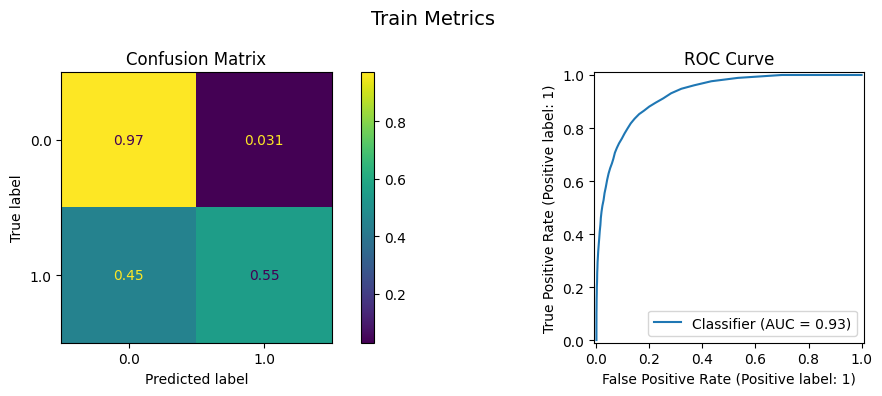

=== Validation ===
AUROC:    0.9187
F1 Score: 0.6470


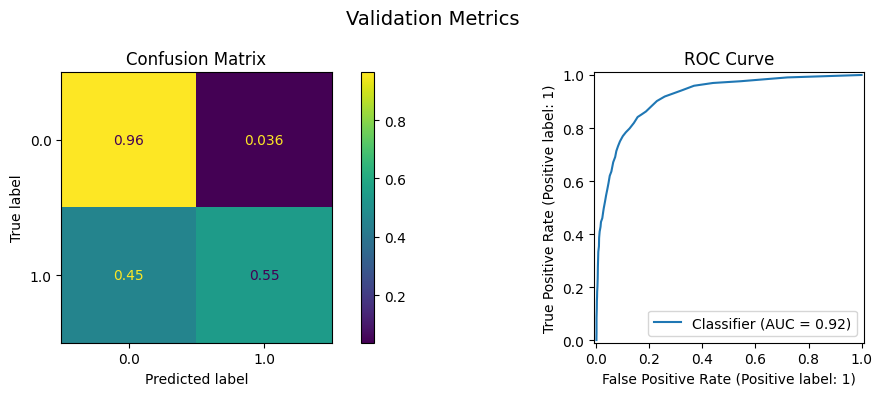

In [5]:
knn_best = knn_gs.best_estimator_

evaluate_model(knn_best, X_train, train_targets, dataset_name='Train')
evaluate_model(knn_best, X_val, val_targets, dataset_name='Validation');

Модель значно покращилась - різниця між тренувальними / валідаційними даними зменшилась.
Точність вийшла приблизно така ж, як і в попередньому ДЗ (чуть гірше)

3. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `GridSearchCV` за сіткою параметрів
  - `max_depth` від 1 до 20 з кроком 2
  - `max_leaf_nodes` від 2 до 10 з кроком 1

  Обовʼязково при цьому ініціюйте модель з фіксацією `random_state`.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `dt_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли вручну?

In [6]:
dt = DecisionTreeClassifier(random_state=42)
params_dt = {'max_depth': np.arange(1, 21, 2), 'max_leaf_nodes' : np.arange(2, 11, 1)}

In [7]:
%%time
dt_gs = GridSearchCV(dt, params_dt, cv=3, scoring='roc_auc')
dt_gs.fit(X_train, train_targets)

CPU times: user 2.53 s, sys: 22.6 ms, total: 2.55 s
Wall time: 2.55 s


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'max_depth': array([ 1, 3..., 15, 17, 19]), 'max_leaf_nodes': array([ 2, 3..., 8, 9, 10])}"
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [8]:
print("Best params:", dt_gs.best_params_)
print("Best CV AUROC:", dt_gs.best_score_)

dt_best = dt_gs.best_estimator_

evaluate_model(dt_best, X_train, train_targets, dataset_name='Train', plot = False)
evaluate_model(dt_best, X_val, val_targets, dataset_name='Validation', plot = False);

Best params: {'max_depth': np.int64(5), 'max_leaf_nodes': np.int64(10)}
Best CV AUROC: 0.896755388100145
=== Train ===
AUROC:    0.9010
F1 Score: 0.6692
=== Validation ===
AUROC:    0.9018
F1 Score: 0.6569


Результат трохи гірший, ніж я знайшла вручну в попередньому ДЗ (max_leaf_nodes=25, max_depth=5), отож хочеться пошукати ще раз з більшим діапазоном для max_leaf_nodes:

In [9]:
params_dt = {'max_depth': np.arange(1, 21, 2), 'max_leaf_nodes' : np.arange(2, 51, 2)}

In [10]:
%%time
dt_gs = GridSearchCV(dt, params_dt, cv=3, scoring='roc_auc')
dt_gs.fit(X_train, train_targets)

CPU times: user 8.85 s, sys: 58.8 ms, total: 8.91 s
Wall time: 8.91 s


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'max_depth': array([ 1, 3..., 15, 17, 19]), 'max_leaf_nodes': array([ 2, 4..., 46, 48, 50])}"
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [11]:
print("Best params:", dt_gs.best_params_)
print("Best CV AUROC:", dt_gs.best_score_)

dt_best = dt_gs.best_estimator_

evaluate_model(dt_best, X_train, train_targets, dataset_name='Train', plot = False)
evaluate_model(dt_best, X_val, val_targets, dataset_name='Validation', plot = False);

Best params: {'max_depth': np.int64(7), 'max_leaf_nodes': np.int64(36)}
Best CV AUROC: 0.9189078843621618
=== Train ===
AUROC:    0.9229
F1 Score: 0.7464
=== Validation ===
AUROC:    0.9203
F1 Score: 0.7164


Вдалось трошки покращити :)

4. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `RandomizedSearchCV` за заданою сіткою параметрів і кількість ітерацій 40.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, зафіксуйте `random_seed` процедури крос валідації та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_random_search_best` найкращу модель, знайдену з `RandomizedSearchCV`
    - оцініть якість передбачень  `dt_random_search_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли з `GridSearch`?
    - проаналізуйте параметри `dt_random_search_best` і порівняйте з параметрами `dt_best` - яку бачите відмінність? Ця вправа потрібна аби зрозуміти, як різні налаштування `DecisionTreeClassifier` впливають на якість моделі.

In [12]:
params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 20),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

In [13]:
%%time

dt_rs = RandomizedSearchCV(
    dt,
    params_dt,
    n_iter = 40,
    cv=3,
    scoring="roc_auc",
    refit=True,
    random_state = 42
)
dt_rs.fit(X_train, train_targets)

CPU times: user 546 ms, sys: 6.77 ms, total: 552 ms
Wall time: 552 ms


,estimator,DecisionTreeC...ndom_state=42)
,param_distributions,"{'criterion': ['gini', 'entropy'], 'max_depth': array([ 1, 2... 18, 19]), 'max_features': [None, 'sqrt', ...], 'max_leaf_nodes': array([ 2, 3...8, 19]), ...}"
,n_iter,40
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [14]:
print("Best params:", dt_rs.best_params_)
print("Best CV AUROC:", dt_rs.best_score_)

dt_random_search_best = dt_rs.best_estimator_

evaluate_model(dt_random_search_best, X_train, train_targets, dataset_name='Train', plot = False)
evaluate_model(dt_random_search_best, X_val, val_targets, dataset_name='Validation', plot = False);

Best params: {'splitter': 'best', 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_leaf_nodes': np.int64(14), 'max_features': None, 'max_depth': np.int64(16), 'criterion': 'entropy'}
Best CV AUROC: 0.9118622813318175
=== Train ===
AUROC:    0.9166
F1 Score: 0.7020
=== Validation ===
AUROC:    0.9176
F1 Score: 0.6929


Перше, що кидається в очі - це все ж таки max_leaf_nodes - в пункті 3 мені хотілось збільшити цей range для пошуку, бо в попередньому ДЗ зі значенням 25 було краще.
Тут бачимо покращення (якщо порівнювати з GridSearch для np.arange(2, 11, 1)).
Але спробувавши random search з 'max_leaf_nodes': np.arange(2, 61) - виходить ще краще

In [15]:
params_dt['max_leaf_nodes'] = np.arange(2, 51)
dt_rs = RandomizedSearchCV(
    dt,
    params_dt,
    n_iter = 40,
    cv=3,
    scoring="roc_auc",
    refit=True,
    random_state = 42
)
dt_rs.fit(X_train, train_targets)
print("Best params:", dt_rs.best_params_)
print("Best CV AUROC:", dt_rs.best_score_)

dt_random_search_best = dt_rs.best_estimator_
evaluate_model(dt_random_search_best, X_train, train_targets, dataset_name='Train', plot = False)
evaluate_model(dt_random_search_best, X_val, val_targets, dataset_name='Validation', plot = False);

Best params: {'splitter': 'random', 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_leaf_nodes': np.int64(50), 'max_features': None, 'max_depth': np.int64(8), 'criterion': 'entropy'}
Best CV AUROC: 0.9167629408520365
=== Train ===
AUROC:    0.9244
F1 Score: 0.7157
=== Validation ===
AUROC:    0.9227
F1 Score: 0.7205


5. Якщо у Вас вийшла метрика `AUROC` в цій серії експериментів - зробіть ще один `submission` на Kaggle і додайте код для цього і скріншот скора на публічному лідерборді нижче.

  Сподіваюсь на цьому етапі ви вже відчули себе справжнім дослідником 😉

In [16]:
test_raw_df = pd.read_csv('test.csv')
test_result = preprocess_new_data(
        test_raw_df,
        encoder=data["encoder"],
        scaler = data['scaler'],
        feature_cols=data["feature_cols"],
        numeric_cols=data["numeric_cols"],
        scale_numeric=True
    )

probas = get_predictions(dt_random_search_best, test_result['X_new'])[1]

In [17]:
sample_submission = pd.read_csv('sample_submission.csv')
sample_submission['Exited'] = probas

sample_submission.to_csv('submission_dt_rsearch.csv', index=False)

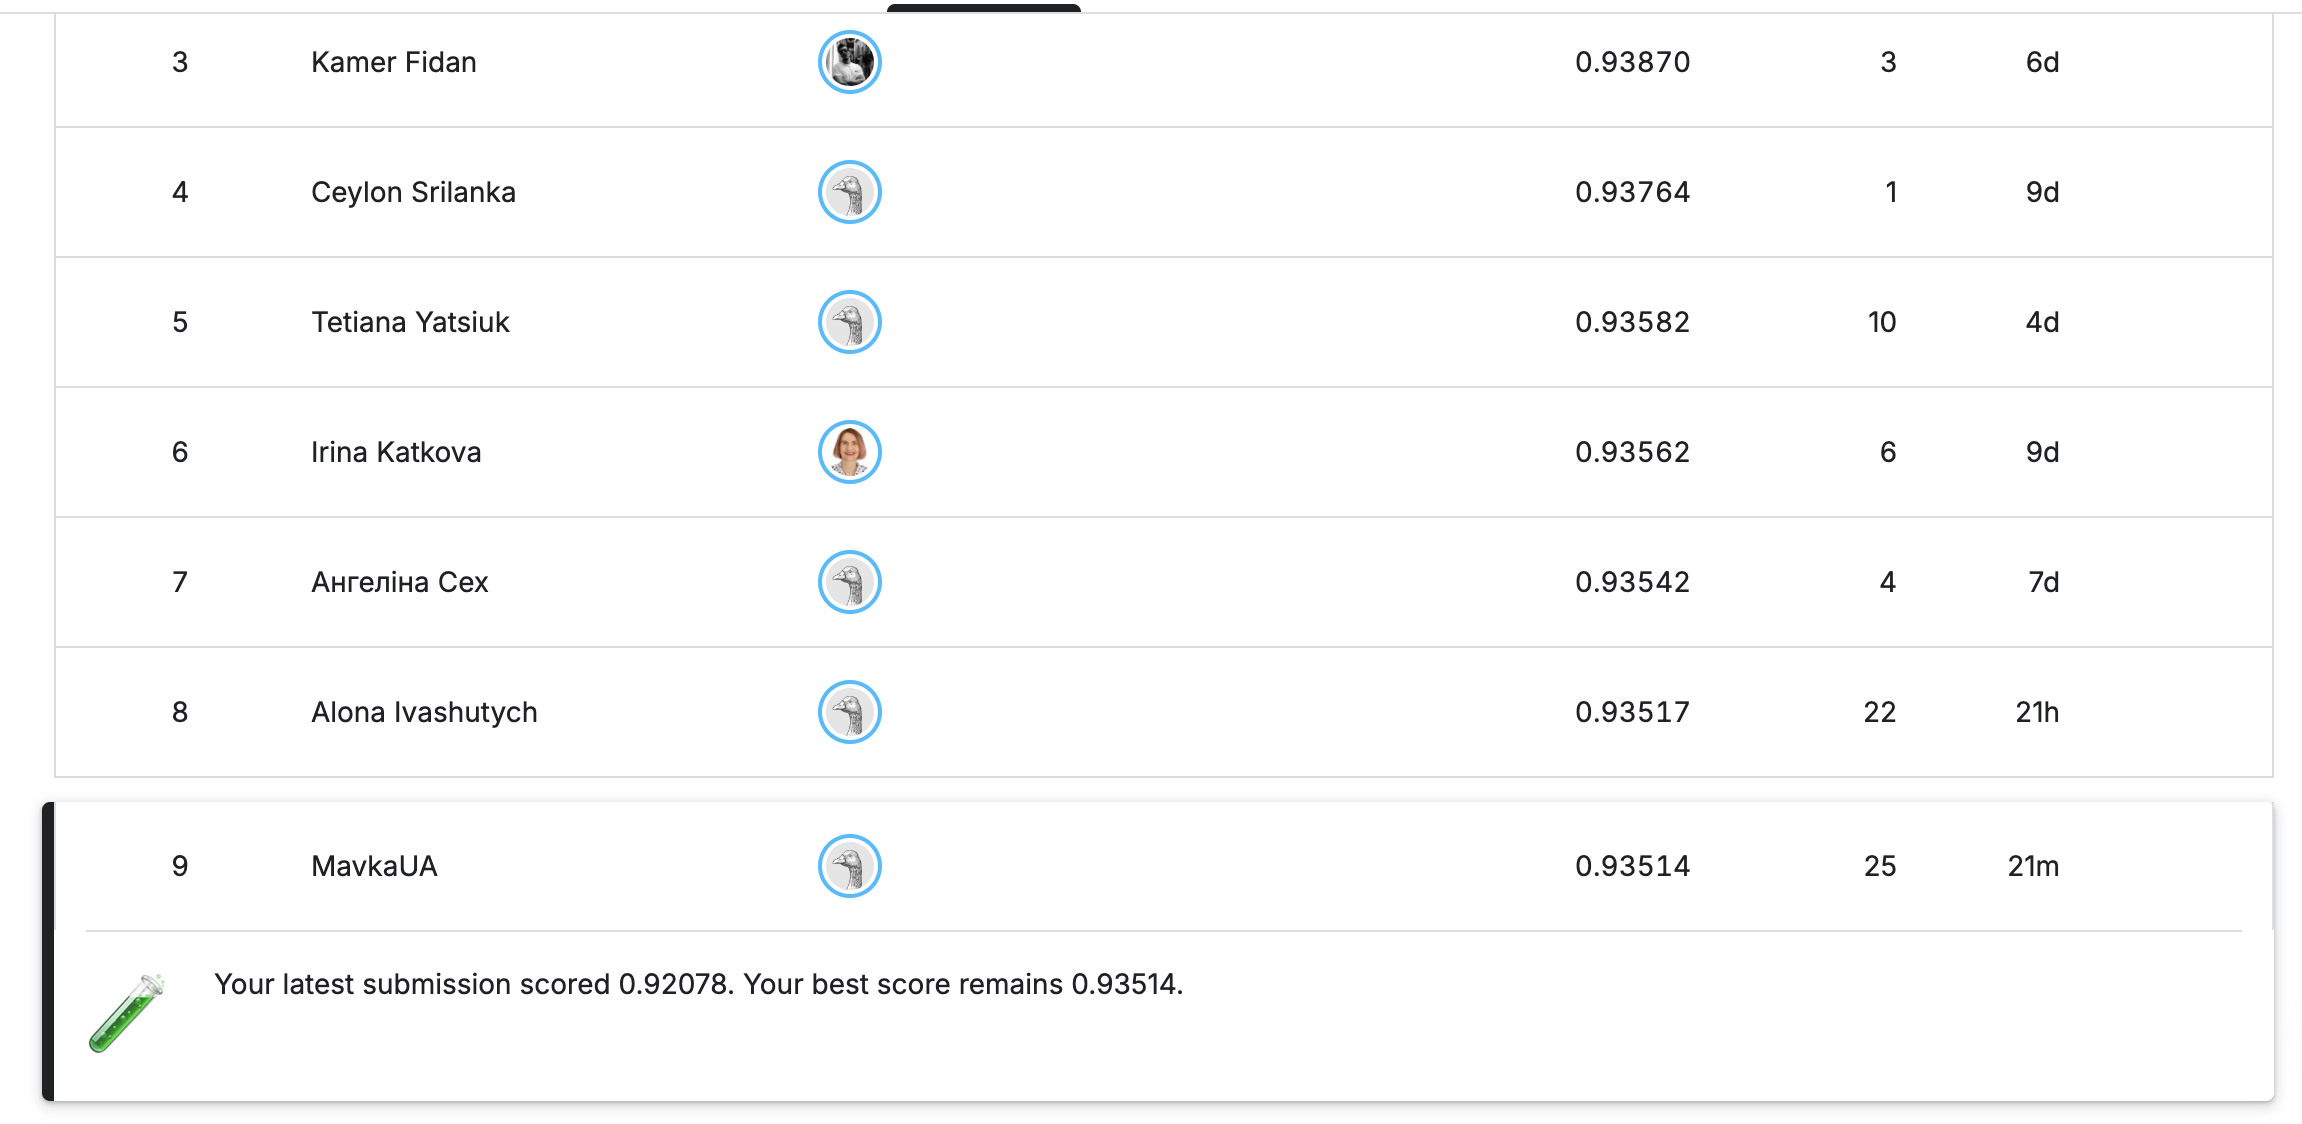
Score поки не вдалось покращити (порівняно з результатом логістичної регресії)